In [1]:
from time import time
import numpy as np
import tensorflow as tf
# from tensorflow.keras import backend as K # type: ignore
from tensorflow.keras.optimizers.legacy import Adam, Adamax  # type: ignore
from tensorflow.keras.layers import Layer, InputSpec, Flatten, Reshape, Conv2DTranspose  # type: ignore
from tensorflow.keras.models import Model  # type: ignore
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices('GPU'))

2.14.1
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import os, tensorflow as tf
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # 0=all, 1=INFO, 2=WARNING, 3=ERROR
tf.get_logger().setLevel("ERROR")         # réduit encore le verbiage

## __`I. TP Deep Clustering`__ 

__L'objectif de ce TP consiste à créer un modèle constitué de plusieurs parties :__

1. Un auto-codeur, pré-entraîné pour apprendre la représentation condensée initiale des jeux de données non étiquetés.
2. Une couche de clustering empilée sur l'encodeur pour affecter la sortie de l'encodeur à un cluster. 
3. Les poids de la couche de clustering sont initialisés avec les centres de cluster de K-Means.
3. Entraîner le modèle de clustering pour affiner la couche de clustering et le codeur conjointement.

`L’encoder + k‑means en non supervisé :`
 - Pipeline non supervisé encoder + k‑means
 - Pré‑entraînement non supervisé de l’encoder

`Autoencoder :` 
 - Nous apprennons à reconstruire l’image, donc l’espace latent z se structure sans labels.
 - La méthode type DEC / Deep Embedded K‑Means.
 - Pour laquelle l’encoder est entraîné avec une loss qui dépend des clusters (distribution cible, KL, etc.).

`Clustering dans l'espace latent`
 - On passe les images dans l’encoder, 
 - On récupère les embeddings $z_i$, 
 - On applique k‑means sur les ${z_i}$.

`Les indices de clusters de k‑means sont les pseudo‑labels non supervisés`.
 - Option de raffinement (deep embedded clustering)
 - On ré‑entraîne l’encoder en forçant les embeddings à se rapprocher des centres de leurs clusters 
 - La loss basée sur la KL entre assignations et une distribution cible plus « piquée ).
 - Les « étiquettes » sont produites par k‑means à partir des features apprises, non pas par un annotateur.

### `1.1 Chargement des données`

In [4]:
from keras.datasets import mnist  # type: ignore
from keras.datasets import fashion_mnist  # type: ignore à tester, + complexe que l'ensemble mnist 

import numpy as np

# Chargement et normalisation (entre 0 et 1) des données de la base de données MNIST/Fashion mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(f"x_train.shape : {x_train.shape}")

x_train_rshp = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test_rshp  = x_test.reshape(-1, 784).astype("float32") / 255.0

print(f"x_train_rshp.shape : {x_train_rshp.shape}")

x_train.shape : (60000, 28, 28)
x_train_rshp.shape : (60000, 784)


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(2,2))
plt.imshow(x_train[0], cmap='gray')
plt.axis('off')
plt.show()

### __`1.2 Clustering avec kmeans à l'aide d'un autoencoder classique`__

#### ` 1.2.1 Prédiction KMEANS` 
- C'est un vecteur d’entiers de taille (n_samples,) 
- Il contient l’indice du cluster auquel KMeans a affecté chaque occurence (0, 1, ..., n_clusters-1)
- Il n’y a pas de correspondance directe entre indice de cluster et l'indice des classes. 
- Les indices de KMeans sont arbitraires

In [14]:
# Nombre de classes à trouver
n_clusters=10
# nombre de chiffres
n_digits = len(np.unique(y_test))
print(f"n_digits : {n_digits}")
# Initialisation du Kmeans 
kmeans = MiniBatchKMeans(n_clusters = n_digits)

# Appliquer Kmeans sur base d'apprentissage
y_pred_kmeans = kmeans.fit_predict(x_train_rshp)
print(f"y_pred_kmeans.shape : {y_pred_kmeans.shape}")
print(f"y_pred_kmeans : {y_pred_kmeans}")

n_digits : 10
y_pred_kmeans.shape : (60000,)
y_pred_kmeans : [4 7 2 ... 8 7 8]


#### `1.2.3 Accuracy KMeans n’a pas de sens`

KMeans retourne les numéro de cluster et pas le label de la classe

In [ ]:
# Score de performance
acc = accuracy_score(y_train,y_pred_kmeans)
print(f"Cette valeur d'accuracy pour KMeans (fit_predict) n'a pas de sens : {acc:.4f}")

### `1.3 Attribution des étiquettes de cluster`

 - La classification K-means est une méthode d'apprentissage automatique non supervisée
 - Les étiquettes KMeans référence la classification attribuée à chaque élément et non à l'entier cible réel
 - Les fonctions ci-dessous permettent de prédir à quelle classe correspond à chaque cluster

#### `1.3.1 Correspondance étiquette Cluster/Label`
- Calcule, pour chaque cluster, la classe majoritaire dans ce cluster 
- Renvoie un tableau reference_labels qui fait la correspondance
- Reference_labels[i] = classe majoritaire parmi les points du cluster i.
- La fonction correspondance effectue le mapping numéro de cluster classe réel 
- Pour chaque prédiction cluster d'un élement associe la classe correspondante

In [5]:
def retrieve_info(cluster_labels, y_train, n_clusters=None):
    if n_clusters is None:
        n_clusters = np.max(cluster_labels) + 1
    reference_labels = np.zeros(n_clusters, dtype=int)
    for i in range(n_clusters):
        index = (cluster_labels == i)
        if not np.any(index):
            # cluster vide: on peut laisser 0 ou un label spécial
            # print(f"cluster {i} vide")
            continue
        majority = np.bincount(y_train[index]).argmax()
        reference_labels[i] = majority
    return reference_labels

In [6]:
def correspondance(y_pred_kmeans, y_train):
    reference_labels = retrieve_info(y_pred_kmeans, y_train)
    number_labels = np.zeros(len(y_pred_kmeans), dtype=int)
    for i, c in enumerate(y_pred_kmeans):
        number_labels[i] = reference_labels[c]
    return number_labels

#### `1.3.2 Obtenir un score de performance`
- Après la correspondance clusters → classes, 
- Utiliser _reference_labels_ pour transformer les labels de clusters en labels de classes, 
- puis calculer une accuracy classique.

In [ ]:
# labels prédits (après correspondance cluster -> classe)
y_train_pred = correspondance(y_pred_kmeans, y_train)
print(f"y_train_pred.shape : {y_train_pred.shape}")

# score de performance sur l'apprentissage
score = accuracy_score(y_train, y_train_pred)
print(f"Accuracy KMeans (apprentissage) : {score:.4f}")

### `II. Affichage`

In [ ]:
# Affichage des données 
inputs = x_train_rshp
classes = y_train
embedTSNE = TSNE(n_components=2).fit_transform(inputs)

In [16]:
import matplotlib.pyplot as plt

def display_2Dreduce(classes,embedTSNE=[] ,embedPCA=[], mode=("TSNE", "PCA")):
    """
    mode peut contenir :
      - ("TSNE", "PCA")  -> les deux graphiques côte à côte
      - ("TSNE",)        -> uniquement t-SNE
      - ("PCA",)         -> uniquement PCA
    """
    color = classes.astype(int)

    show_tsne = "TSNE" in mode
    show_pca  = "PCA" in mode

    if show_tsne and show_pca:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        ax = axes[0]
        sc = ax.scatter(embedTSNE[:, 0], embedTSNE[:, 1],c=color, cmap="Spectral", s=5, alpha=0.8)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title("MNIST en 2D par t-SNE", fontsize=8)
        fig.colorbar(sc, ax=ax)

        ax = axes[1]
        sc = ax.scatter(embedPCA[:, 0], embedPCA[:, 1],c=color, cmap="Spectral", s=5, alpha=0.8)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title("MNIST en 2D par PCA", fontsize=8)
        fig.colorbar(sc, ax=ax)

        plt.tight_layout()
        plt.show()

    elif show_tsne:
        fig, ax = plt.subplots(figsize=(4, 3))
        sc = ax.scatter(embedTSNE[:, 0], embedTSNE[:, 1],c=color, cmap="Spectral", s=5, alpha=0.8)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title("MNIST en 2D par t-SNE", fontsize=8)
        plt.colorbar(sc)
        plt.show()

    elif show_pca:
        fig, ax = plt.subplots(figsize=(4, 3))
        sc = ax.scatter(embedPCA[:, 0], embedPCA[:, 1],
                        c=color, cmap="Spectral", s=5, alpha=0.8)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title("MNIST en 2D par PCA", fontsize=8)
        plt.colorbar(sc)
        plt.show()

In [ ]:
display_2Dreduce(classes,embedTSNE=embedTSNE, mode=("TSNE"))

### __`III. Autoencodeur classique`__

In [7]:
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense, Input #type: ignore

# Autoencodeur simple pour MNIST (28x28 -> 784)
autoencoder = Sequential([
    Input(shape=(784,)),          # image 28x28 aplatie
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(64, activation="relu",name="latent"), # couche "bottleneck"
    Dense(128, activation="relu"),
    Dense(256, activation="relu"),
    Dense(784, activation="sigmoid")  # reconstruction 784, même taille que l'entrée
])

#### `3.1 Modèle encodeur / décodeur`

In [8]:
# encoder = input -> couche "latent"
x_in = autoencoder.input
z = autoencoder.get_layer("latent").output
encoder = Model(inputs=x_in, outputs=z, name="encoder")

# decoder = latent -> reconstruction (on repart de la couche après "latent")
z_in = Input(shape=(64,))
x = autoencoder.layers[-3](z_in)     # Dense(256, relu)
x = autoencoder.layers[-2](x)     # Dense(512, relu)
x_out = autoencoder.layers[-1](x) # Dense(784, sigmoid)
decoder = Model(inputs=z_in, outputs=x_out, name="decoder")

#### `3.2 AutoEncodeur compilation / apprentissage`
 - z_ae : vecteur latent de taille 64 (sortie de l’encodeur) pour chaque image.

In [33]:
# encodeur(x) -> z
z_ae = encoder(x_in)
# reconstruction
x_rec = decoder(z_ae)
# tête de classif sur le latent
model_ae = Model(inputs=x_in, outputs=x_rec, name="model_ae")

model_ae.compile(
    optimizer=Adam(1e-5), 
    loss="mse",
    metrics=["accuracy"],
)

In [34]:
# x_train_rshp : (60000, 784), y_train : (60000,)
history = model_ae.fit(
    x_train_rshp, x_train_rshp,             # reconstruction + labels
    batch_size=128,
    epochs=20,
    shuffle=True,
    validation_data=(x_test_rshp, x_test_rshp),
)

Epoch 1/20
469/469 [==============================] - 4s 9ms/step - loss: 0.0290 - accuracy: 0.0107 - val_loss: 0.0283 - val_accuracy: 0.0094
Epoch 2/20
469/469 [==============================] - 5s 10ms/step - loss: 0.0284 - accuracy: 0.0109 - val_loss: 0.0278 - val_accuracy: 0.0097
Epoch 3/20
469/469 [==============================] - 4s 9ms/step - loss: 0.0280 - accuracy: 0.0109 - val_loss: 0.0273 - val_accuracy: 0.0100
Epoch 4/20
469/469 [==============================] - 4s 9ms/step - loss: 0.0275 - accuracy: 0.0109 - val_loss: 0.0269 - val_accuracy: 0.0094
Epoch 5/20
469/469 [==============================] - 4s 9ms/step - loss: 0.0272 - accuracy: 0.0106 - val_loss: 0.0266 - val_accuracy: 0.0106
Epoch 6/20
469/469 [==============================] - 4s 9ms/step - loss: 0.0268 - accuracy: 0.0106 - val_loss: 0.0262 - val_accuracy: 0.0101
Epoch 7/20
469/469 [==============================] - 4s 9ms/step - loss: 0.0266 - accuracy: 0.0108 - val_loss: 0.0260 - val_accuracy: 0.0100
Epoch

#### `3.3 Affichage de la loss`

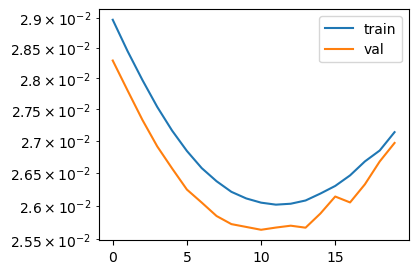

In [35]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend(); plt.yscale("log")

In [36]:
# 1) données aplaties
x_train_flat = x_train.reshape(len(x_train), -1)   # (60000, 784)
x_test_flat  = x_test.reshape(len(x_test), -1)     # (10000, 784)

# 2) encoder dense
encoder = Model(inputs=autoencoder.input,
                outputs=autoencoder.get_layer("latent").output)  # (None, 64)

z_train = encoder.predict(x_train_flat, batch_size=256)  # (N, 64)

# 3) K-means sur z_train
kmeans = KMeans(n_clusters=10, n_init=20)
y_pred = kmeans.fit_predict(z_train)

# 4) accuracy brute de K-means
y_pred_mapped = correspondance(y_pred, y_train)
from sklearn.metrics import accuracy_score
acc_kmeans = accuracy_score(y_train, y_pred_mapped)
print("KMeans on AE latent acc :", acc_kmeans)

235/235 [==============================] - 0s 2ms/step
KMeans on AE latent acc : 0.30616666666666664


#### `3.3 AutoEncodeur architecture`

In [37]:
autoencoder.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               200960    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 latent (Dense)              (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 128)               8320      
                                                                 
 dense_3 (Dense)             (None, 256)               33024     
                                                                 
 dense_4 (Dense)             (None, 784)               201488    
                                                                 
Total params: 484944 (1.85 MB)
Trainable params: 484944 

#### `3.4 Prédiction encoder vs decoder`

1/1 [==============================] - 0s 48ms/step


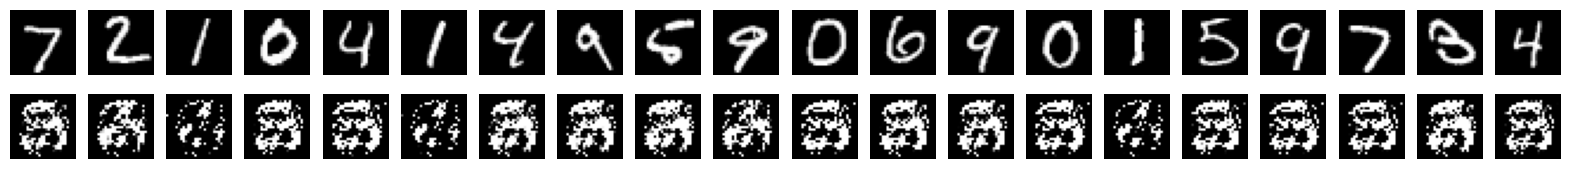

In [38]:
n = 20  # Combien de chiffres nous allons afficher
# Afficher l'image reconstruite à partir de l'espace latent après entraînement
# encoder / decoder
encoded_imgs = encoder.predict(x_test_rshp[:n])
decoded_imgs = decoder.predict(encoded_imgs)

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 2))
for i in range(n):
    # original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_rshp[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # reconstruit
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.show()

#### `3.5 Analyse du résultat`

__Choix de l’architecture__
- Avec un MLP 784-256–128–64–128-256–784, plusieurs facteurs amènent à ce type d’artefact global.
- Compression très forte (784 → 64) avec peu de couches.
- Nous avons atteint (ou presque) la limite de ce que peut faire un autoencoder dense 784→64→784 sur MNIST.
__Couches entièrement connectées :__ 
- Aucune notion de structure spatiale, 
- Donc le modèle peut mélanger des pixels très éloignés, 
- Ceci favorise des motifs globaux bizarres mais “moyens” en termes de MSE.
__Perte pixel-à-pixel (MSE) :__ 
- Le modèle encode surtout un “gabarit moyen” des chiffres plutôt que les détails spécifiques.
- L’optimum est souvent une image moyenne floue qui minimise l’erreur globale, 
- Pas une image nette chiffre-par-chiffre.
__Remarque :__
- une layer à 512 à été ajouté à l'encodeur et au décodeur sans amélioration des résultat.
- l'utilisation de la loss "crossentropy" n'a pas amélioré non plus les résultats.
- l'ajout d'une tête de classification n'a pas eu d'amélioration sur la reconstruction.  
- Les résultats sont mauvais mais cohérents avec le code, l'autoencodeur est correcte.
- Les mesures d'accuracy et de perfs n’ont aucun sens ici, elles sont mauvaises pour des raisons structurelles.
 - La sortie est un vecteur de 784 probabilités (pixels reconstruits).
 - On entraîne avec une loss="mse" et la cible y = x (reconstruction).
 - L’accuracy Keras est une acc de pixel binaire (après seuil implicite), qui n’a rien à voir avec la classification des digits.

`Donc voir ~0.02 d’accuracy est normal et non pertinent.` 
 - Ce n’est pas une accuracy “digit correct / digit faux”, juste une mesure peu informative sur des sorties en [0,1]. 
 - Les reconstructions sont relativement correctes (images originales vs reconstruites).
 - Donc le latent de dimension 64 a de bonnes chances d’être exploitable pour du clustering.

#### `3.6 Représentation PCA vs t-SNE`

1875/1875 [==============================] - 3s 1ms/step
encoded_imgs.shape : (60000, 64)


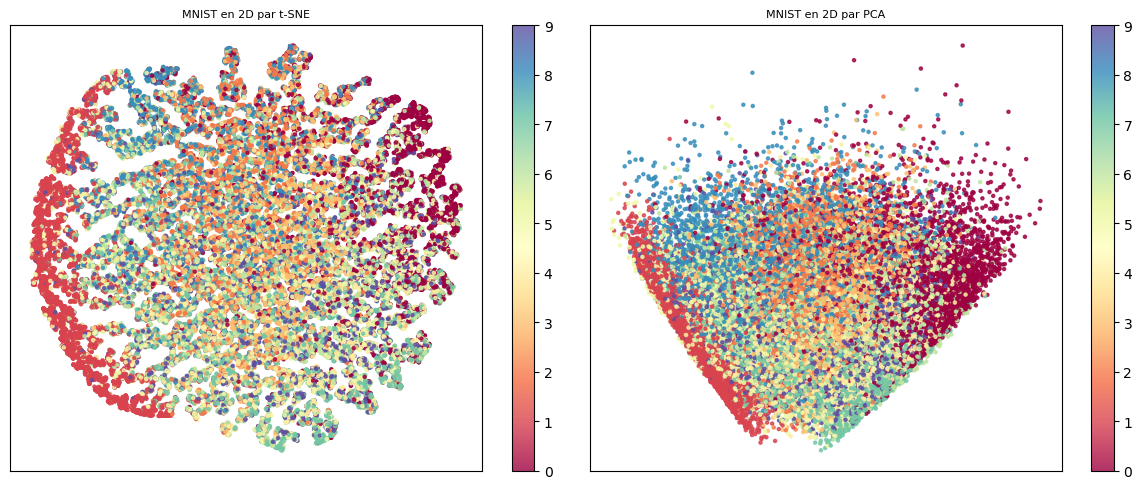

In [39]:
# Affichage de l'espace latent par réduction de dimension 
inputs = x_train_rshp
classes = y_train
# Récupération des données dans l'espace latent
encoded_imgs = encoder.predict(x_train_rshp)
print(f"encoded_imgs.shape : {encoded_imgs.shape}")
# 1) Réduction de dimension 2D par ACP et affichage
embedPCA = PCA(n_components=2).fit_transform(encoded_imgs)
# 2) Réduction de dimension 2D avec t-SNE
embedTSNE = TSNE(n_components=2).fit_transform(encoded_imgs)
# Affichage de l'espace latent par réduction de dimension ACP vs t-SNE
display_2Dreduce(classes,embedTSNE ,embedPCA, mode=("TSNE", "PCA"))

#### `3.7 Interprétation graphique`
_`t‑SNE sur MNIST`_ 
- t‑SNE capture bien la structure non linéaire des données.
- Montre qu’il existe un embedding non linéaire où les classes sont presque parfaitement séparables
- Ceci correspond à ce vers quoi tend avec DEC/IDEC et les autoencodeurs de clustering.

_`PCA sur MNIST`_ 
- La projection PCA est beaucoup plus enchevêtrée (comme un AE linéaire sur les pixels bruts).
- Projète les combinaisons linéaires qui maximisent la variance globale, pas la structure de clusters.  
- L'autoencodeur linéaire ou K‑means sur les pixels bruts aura du mal à exploiter cette structure, 
- Donc cela nécessité du deep embeddings non linéaires avant le clustering.

#### `3.6 Classification par Kmeans sur l'espace latent`

1875/1875 [==============================] - 2s 1ms/step
Performance de l'autoencodeur : accuracy sur kmeans sur l'espace latent : : 0.5025


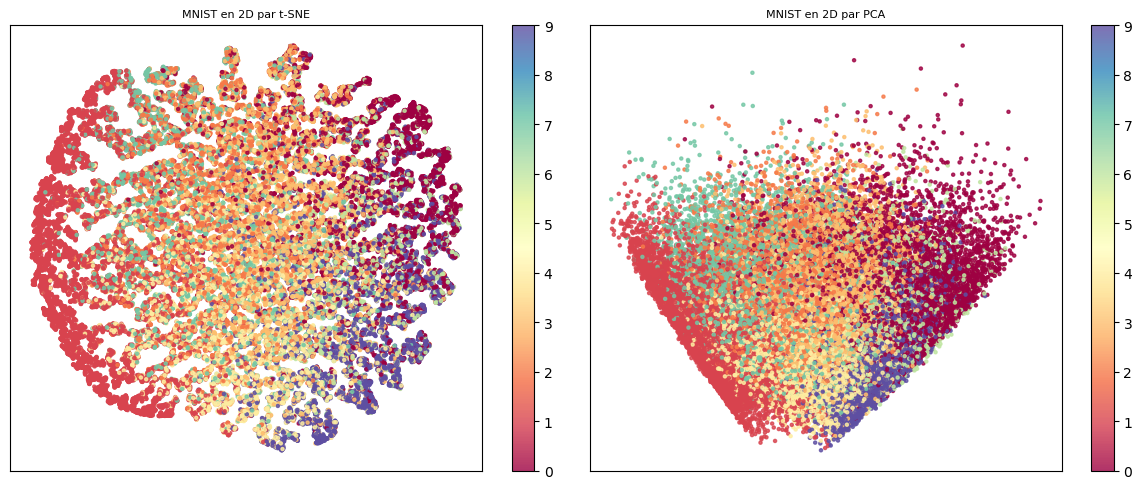

In [40]:
# Classification par kmeans de l'espace latent sur l'ensemble d'apprentissage
# Récupération des données dans l'espace latent
encoded_allimgs = encoder.predict(x_train_rshp)
# Initialisation du Kmeans 
kmeans = MiniBatchKMeans(n_clusters = n_digits)
# Appliquer Kmeans sur base d'apprentissage
y_pred_kmeans = kmeans.fit_predict(x_train_rshp)
# labels prédits (après correspondance cluster -> classe)
y_train_pred = correspondance(y_pred_kmeans, y_train)
# Score de performance sur l'apprentissage
acc = accuracy_score(y_train_pred, y_train)
print(f"Performance de l'autoencodeur : accuracy sur kmeans sur l'espace latent : : {acc:.4f}")
# 2) Réduction de dimension 2D avec PCA
embedPCA = PCA(n_components=2).fit_transform(encoded_allimgs)
# 2) Réduction de dimension 2D avec t-SNE
embedTSNE = TSNE(n_components=2).fit_transform(encoded_allimgs)
# Affichage de l'espace latent par réduction de dimension ACP vs t-SNE
display_2Dreduce(y_train_pred,embedTSNE ,embedPCA, mode=("TSNE", "PCA"))

#### _`3.7 Interprétation graphique`_
- Un accurracy de 0.5814 est une bonne base pour du clustering non supervisé sur MNIST avec un AE dense.
- Le latent appris est plus structuré que l’espace image brut (où K‑means tourne autour de 0.4–0.45).
- Avec t‑SNE, on distingue des amas par chiffre, avec des recouvrements (cohérent avec ~0.58 d’accuracy).
- C’est un point de départ raisonnable pour appliquer DEC/IDEC.
- On peut gagner 0.1–0.2 d’acc en affinant les centres et en ajustant l’encodeur avec la loss de clustering.

### __`IV. Couche de Clustering`__ 
##### _`4.1 Deep Convolutional Embedded Clustering (DCEC)`_
 - Elle ajoute une couche de clustering au-dessus d’un autoencodeur convolutionnel, 
 - Elle précise les formules de $\textcolor{black}{q_{ij}}$, de la loss de clustering de la distribution cible $\textcolor{black}{p_{ij}}$.
`Couche de clustering et soft labels` $\large \textcolor{black}{q_{ij}}$
- Un encodeur $\large \textcolor{black}{f_θ}$ projette chaque image $\large \textcolor{black}{x_i}$ dans un espace latent $\large \textcolor{black}{z_i=f_θ(x_i)}$
 - La couche de clustering maintient des centres de clusters $\textcolor{black}{μ_j}$ (paramètres entraînables).
 - Pour chaque point latent $\textcolor{black}{z_i}$ et chaque centre $\textcolor{black}{μ_j}$, on calcule un soft label $\textcolor{black}{q_{ij}}$ via une distribution t de Student :
##### `4.2 Couche de Clustering Deep Embedded Clustering (DEC)`
1. Elle prend un vecteur de caractéristiques (la sortie de l'encodeur) 
2. Le transforme en probabilités d’appartenance aux clusters via une `distribution t de Student`.
3. La couche de clustering maintient les centres de cluster $\textcolor{black}{µ_j}$ comme poids entraînables 
4. Elle projette chaque point intégré $\textcolor{black}{z_i}$ en soft label $\textcolor{black}{q_i}$ par la distribution $t$ de Student 
5. Elle est utilisée comme noyau pour mesurer la similarité entre $\textcolor{black}{zi = fθ(x_i)}$ et le centroïd $\textcolor{black}{µ_j}$ :
$$\textcolor{black}{q_{ij}=\frac{(1+\|z_i-\mu_j\|^2)^{-1}}{\sum_j(1+\|z_i-\mu_j\|^2)^{-1}}}$$
 - $\textcolor{black}{q_{ij}}$ est la $\textcolor{black}{j^{ième}}$ entrée du vecteur $\textcolor{black}{q_i}$, représentant la probabilité d'appartenance de $\textcolor{black}{z_i}$ au cluster $\textcolor{black}{j}$
 - La normalisation au dénominateur fait que $\textcolor{black}{\sum_j q_{ij} = 1}$ pour chaque $\textcolor{black}{i}$
 $\textcolor{black}{\text{C’est ce que fait la classe ClusteringLayer ci-dessous }}$: 
- distances au carré, noyau __t__ de Student, puis normalisation par ligne.

In [41]:
class ClusteringLayer(Layer):

    def __init__(self, n_clusters, weights=None, alpha=1.0, **kwargs):
        if 'input_shape' not in kwargs and 'input_dim' in kwargs:
            kwargs['input_shape'] = (kwargs.pop('input_dim'),)
        super(ClusteringLayer, self).__init__(**kwargs)
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.initial_weights = weights
        self.input_spec = InputSpec(ndim=2)

    def build(self, input_shape):
        assert len(input_shape) == 2
        input_dim = input_shape[1]
        self.input_spec = InputSpec(dtype=tf.float32, shape=(None, input_dim))
        self.clusters = self.add_weight(
            shape=(self.n_clusters, input_dim), 
            initializer='glorot_uniform', 
            name='clusters')
        if self.initial_weights is not None:
            self.set_weights(self.initial_weights)
            del self.initial_weights
        self.built = True

    # Distribution t de student, la même que celle utilisée dans l'algorithme t-SNE.
    # q_ij = 1/(1+dist(x_i, u_j)^2), puis normalisation.
    # Arguments : inputs : la variable contenant les données, shape=(n_samples, n_features)
    # Retourne  : q la distribution t de student, ou des étiquettes souples pour chaque échantillon. shape=(n_samples, n_clusters)
    # Cette méthode call est celle de ta ClusteringLayer (DEC/IDEC). 
    # Elle transforme les embeddings latents en probabilités de cluster via un noyau t de Student.
    def call(self, inputs, **kwargs):
      # distance au carré entre chaque point et chaque centroïde
        diff = tf.expand_dims(inputs, axis=1) - self.clusters
        dist_sq = tf.reduce_sum(tf.square(diff), axis=2)
        # Applique la distribution t Student
        q = 1.0 / (1.0 + dist_sq / self.alpha)
        q **= (self.alpha + 1.0) / 2.0                  # noyau t de Student
        # Normalisation par ligne : chaque qi devient une distribution de probas 
        # qui somme à 1 sur les clusters. C’est ce qu’on appelle les soft assignments qij.
        q = q / tf.reduce_sum(q, axis=1, keepdims=True) # normalisation par ligne
        return q # Shape : (batch_size, n_clusters).

    def compute_output_shape(self, input_shape):
        assert input_shape and len(input_shape) == 2
        return input_shape[0], self.n_clusters

    def get_config(self):
        config = {'n_clusters': self.n_clusters}
        base_config = super(ClusteringLayer, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))


Quand on écrit clustering_out = ClusteringLayer(...)(latent_input), Keras :
 - création d'une instance de ClusteringLayer,
 - puis enregistre qu’elle doit être appelée avec latent_input,
 - lors du build, appelle build() avec la shape de latent_input,
 - à l’exécution (forward), appelle call(inputs) pour calculer q.
 - lors du predict appelle ClusteringLayer.call() model_DEC.predict(z_batch)     
 - lors du fit la passe avant (feedforward) appelle ClusteringLayer.call()


#### _`4.3 IDEC (Improved Deep Embedded Clustering)`_ 

In [ ]:
from IPython.display import Image, display # type: ignore
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TP2_DeepClustering/images/DeepClustering.png",width=600))

C’est un algorithme de deep clustering qui part d’un autoencodeur “embedded” comme DEC, ajoute la loss de reconstruction en plus de la loss de clustering (KL), optimise les deux conjointement pour préserver la structure locale tout en améliorant la qualité des clusters

 - Modèle à 2 sorties optimisé par une loss jointe “reconstruction + clustering”, avec un coefficient γ. 
 - D’un point de vue Keras, c’est un modèle multi‑sorties avec une loss multi‑tâches pondérée :

   - outputs=[autoencoder.output, clustering_out],
   - loss=["binary_crossentropy", "kld"],
   - loss_weights=[1.0, gamma].

 - L’objectif IDEC : $L_{total}=L_r+γL_c$
   - $L_r$ loss de reconstruction (binary_crossentropy) et $L_c$ loss de clustering (kld entre p et q).
   - “un modèle IDEC avec optimisation jointe reconstruction + clustering”
   - ou plus génériquement “un multi‑task learning avec loss combinée. 

##### `4.3 La distribution de probabilté «t de Student»` 
C'est une distribution de probabilité, qui est utilisée comme noyau pour mesurer la similarité entre 
- Un point latent $\textcolor{black}{x_i}$ 
- Un centroïde $\textcolor{black}{u_j}$,
- Puis on normalise sur $\textcolor{black}{j}$ pour obtenir une distribution de probabilité sur les clusters (soft labels)
 $$\textcolor{black}{q_{ij} \propto \left( 1 + \frac{\lVert x_i - u_j \rVert^{2}}{\alpha} \right)^{\large -\frac{\alpha + 1}{2}}}$$
Contrairement à `KMeans classique (hard labels)`, on obtient des assignations molles (soft assignments). 
Comme cette couche est différentiable et intégrée au réseau, on peut apprendre conjointement :
- la représentation latente (l’encodeur),
- les centres de clusters (self.clusters), en minimisant par exemple une Kullback–Leibler 
- Cette `KL` s'effectue entre la distribution $\textcolor{black}{q}$ et la distribution cible $\textcolor{black}{p}$ (c’est DEC).

##### `4.4 Divergence de Kullback–Leibler` $\textcolor{brown}{D_{KL}}$ 
$$\textcolor{black}{D_{\text{KL}}(P \parallel Q)= \sum_{x \in X} P(x)\,\log \frac{P(x)}{Q(x)}}$$
 - Quantifie à quel point une distribution de probabilité $\textcolor{black}{Q}$ est différente d’une distribution «vraie» $\textcolor{black}{P}$
 - Considérons : 
    - $\textcolor{black}{P}$ soit la « vraie » loi des données 
    - $\textcolor{black}{Q}$ une approximation (modèle)
$\textcolor{black}{D_{KL}(P||Q)}$ mesure la perte d’information moyenne, si on encodait telles que : 
 - elles suivaient $\textcolor{black}{Q}$ alors qu’elles suivent en réalité $\textcolor{black}{P}$
 - si $\textcolor{black}{P = Q}$, la divergence est 0 (pas de perte).
 - plus $Q$ est différent de $\textcolor{black}{P}$ plus le $\textcolor{black}{KL}$ est grand.

__Perte de clustering $L_c$ = divergence KL entre P et Q__
 - On note $Q=(q_{ij})$ la distribution de soft labels produite par la couche de clustering.
 - On définit une distribution cible $P=(p_{ij})$
 - La loss de clustering est une divergence de Kullback–Leibler :
 $$\textcolor{black}{L_c = KL(P \parallel Q)= \sum_i \sum_j p_{ij} \log \frac{p_{ij}}{q_{ij}}}$$
Avec les autoencodeurs / clustering profonds, on minimise souvent une KL entre 
- une distribution cible P et 
- la distribution de clusters produite par le modèle Q


##### _`4.5. Distribution P cible`_ 
 - $\textcolor{black}{p_{ij}}$ est la $\textcolor{black}{j^{ième}}$ entrée de $\textcolor{black}{p_i}$ représentant la probabilité d'appartenance de la donnée $\textcolor{black}{i}$ la classe $\textcolor{black}{j}$
 - Dans DEC, la distribution cible  $\textcolor{black}{P=(p_{ij}})$ se calcule à partir de $\textcolor{black}{Q=(q_{ij}}$) (la sortie de ta ClusteringLayer) en renforçant les assignations confiantes.

 - `La formule standard est :` $\Large \textcolor{black}{p_{ij}=\frac{q_{ij}^2/\sum_i q_{ij}}{\sum_j (q_{ij}^2/\sum_i q_{ij})}}$


In [42]:
import numpy as np

def target_distribution(q):
    eps = 1e-8
    weight = q ** 2 / (q.sum(axis=0, keepdims=True) + eps)
    return (weight.T / (weight.sum(axis=1) + eps)).T

#### _`4.6 Préparation des données`_

In [43]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

inputs = x_train
print(len(x_train))
n_samples = len(inputs)
x_trainIm = inputs.astype('float32') / 255
x_train_rshp = np.reshape(x_trainIm, (len(x_trainIm), 784))
print(x_train_rshp.shape)
#x_trainrshp = np.asarray(x_trainrshp) 

60000
(60000, 784)


#### _`4.7 Definition du DEC`_

In [ ]:
from IPython.display import Image, display # type: ignore
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TP2_DeepClustering/images/AE-KmeansCluster.png",width=400))

##### _`4.7.1 Autoencodeur initial`_
D’abord un autoencodeur pré‑entraîné :
- encoder: $x ↦ z$ (espace latent)
- decoder: $z ↦ \hat{x}$
- autoencoder: $x ↦ \hat{x}$
Après pré‑entraînement, les poids de encoder sont fixés, on va les réutiliser dans DEC.
##### _`4.7.2 Modèle DEC`_
 - x → encoder → z → ClusteringLayer → q : Model(inputs=encoder.input, outputs=clustering_layer)
 - Pendant l’entraînement DEC : MAJ des poids de l’encodeur + les centroïdes $μ_j$ dans ClusteringLayer
 - Encoder entraîné: Après training DEC, on veut récupérer le nouvel espace latent z (encodeur affiné)
 - Deux options :  
   - on réutilise directement encoder (ses poids ont été modifiés par DEC, car ils sont partagés).
   - on construit une vue explicite encoder_trained = Model(inputs=model.input,outputs=encoder.output)


L'algorithme part d’un AE “embedded” comme DEC, ajoutant la loss de reconstruction en plus de la loss de clustering (KL), qui optimise les deux conjointement préservant la structure locale en améliorant la qualité des clusters.
- Modèle à 2 sorties optimisé par une loss jointe “reconstruction + clustering”, avec un coefficient γ. 
- D’un point de vue Keras, c’est un modèle multi‑sorties avec une loss multi‑tâches pondérée :

In [44]:
def buildModel(x_train_cnn,lr,loss, n_clusters,gamma=1):
    # x_train_cnn : (N, 28, 28, 1)
    z_conv = encoder.predict(x_train_cnn, batch_size=256)  # (N, H, W, C)
    N = z_conv.shape[0]
    z_flat = z_conv.reshape(N, -1)                         # (N, latent_dim)

    kmeans = KMeans(n_clusters=n_clusters, n_init=20)
    y_pred = kmeans.fit_predict(z_flat)
    y_pred_last = np.copy(y_pred)
    μj = kmeans.cluster_centers_                           # (n_clusters, latent_dim)

    # même flatten dans le graphe Keras
    z_flatten = Flatten(name="flatten_for_cluster")(encoder.output)  # (None, latent_dim)
    clustering_layer = ClusteringLayer(n_clusters, name="clustering")(z_flatten)
    model = Model(inputs=encoder.input, outputs=[clustering_layer,autoencoder.output])
    model.get_layer("clustering").set_weights([μj])
    model.compile(
            optimizer=Adam(lr),
            loss=loss,
            loss_weights=[1.0, gamma]
            )
    return model, clustering_layer, y_pred_last, z_flatten, μj


 - L’objectif IDEC : $L_{total}=L_r+γL_c$
   - $L_r$ loss de reconstruction (binary_crossentropy) et $L_c$ loss de clustering (kld entre p et q).
   - “un modèle IDEC avec optimisation jointe reconstruction + clustering”
   - ou plus génériquement “un multi‑task learning avec loss combinée. 

In [53]:
gamma=1
lr=1e-4
loss=["kld","mse"]
model_IDEC, clustering_layer, y_pred_last, z_flatten, μj = buildModel(x_train_rshp,lr,loss, 
                                                                     n_clusters,gamma)

235/235 [==============================] - 0s 1ms/step


##### _`4.7.1 Axes d'amélioration`_

:::
- Augmenter le poids de la loss de clustering (γ) et jouer sur le LR (ex. γ∈{0.5,1,2}, lr plus petit).
- Mettre à jour P moins souvent (toutes les 1–5 epochs complètes), 
- Permet de laisser le temps au réseau de s’adapter à une cible quasi fixe.
- Renforcer un peu le latent (par ex. 7×7×64 → 7×7×128 
- Ou bien ajouter une couche Dense dans le bottleneck) puis refaire KMeans + IDEC.
:::

#### _`4.8. Phase d'apprentissage`_ 

In [46]:
# paramètres à fixer
loss = 0.0
index = 0

maxiter = 5000
batch_size = 64
update_interval = 937   #

index_array = np.arange(x_train.shape[0])
tol = 1e-3 # seuil pour critère d'arrêt

##### _`4.8.1 Lecture globale de la boucle`_
__Tous les update_interval itérations :__
 - on recalcule `Q`,
 - on ,construit `P`,
 - on évalue l’accuracy et la convergence (delta de labels).

__À chaque itération :__
- on prend un batch (x_batch, p_batch) → train_on_batch.

In [ ]:
from IPython.display import Image, display # type: ignore
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TP2_DeepClustering/images/AE-optimisation.png",width=400))

In [47]:
def trainingModel_DEC(model_DEC, x_train, y_train, y_pred_last,
                      index, batch_size, tol,
                      update_interval, maxiter, index_array):

    logs = None
    for ite in range(int(maxiter)):

        if ite % update_interval == 0:
            q = model_DEC.predict(x_train, batch_size=batch_size, verbose=0)  # (N, K)
            p = target_distribution(q)

            y_pred = q.argmax(axis=1)
            if y_train is not None:
                y_pred_mapped = correspondance(y_pred, y_train)
                acc = np.round(accuracy_score(y_train, y_pred_mapped), 5)
                print('(Iter , acc)  ', (ite, acc))

            delta_label = np.mean(y_pred != y_pred_last)
            y_pred_last = np.copy(y_pred)

            if ite > 0 and delta_label < tol:
                print('Reached tolerance threshold. Stopping training.')
                break

        idx = index_array[index * batch_size:
                          min((index + 1) * batch_size, x_train.shape[0])]
        x_batch = x_train[idx]
        p_batch = p[idx]

        logs = model_DEC.train_on_batch(x_batch, p_batch, return_dict=True)
        index = index + 1 if (index + 1) * batch_size <= x_train.shape[0] else 0

    return index, logs


In [55]:
def trainingModel_IDEC(idec, x_train, y_train, y_pred_last,
                       index, batch_size, tol,
                       update_interval, maxiter, index_array):

    logs = None
    for ite in range(int(maxiter)):

#(60000, 28, 28, 1)
#(28, 28, 1)
#(28, 1)
        if ite % update_interval == 0:
            q = idec.predict(x_train, batch_size=batch_size, verbose=0)[0]
            print(q.shape)
            p = target_distribution(q)   # q shape (N, K)
            print(p.shape)
            y_pred = q.argmax(axis=1)
            print(y_pred.shape)
            if y_train is not None:
                y_pred_mapped = correspondance(y_pred, y_train)
                acc = np.round(accuracy_score(y_train, y_pred_mapped), 5)
                print('(Iter , acc)  ', (ite, acc),
                      '; loss =', None if logs is None else np.round(logs["loss"], 5))

            delta_label = np.mean(y_pred != y_pred_last)
            y_pred_last = np.copy(y_pred)

            if ite > 0 and delta_label < tol:
                print('Reached tolerance threshold. Stopping training.')
                break

        idx = index_array[index * batch_size:
                          min((index + 1) * batch_size, x_train.shape[0])]
        x_batch = x_train[idx]
        p_batch = p[idx]

        logs = idec.train_on_batch(x_batch, [p_batch, x_batch], return_dict=True)
        index = index + 1 if (index + 1) * batch_size <= x_train.shape[0] else 0

    return index, logs


#### `4.11 Affichage des résultats avec la couche de clustering`

In [49]:
# Affichage de l'impact de cette couche clustering 
inputs = x_test
classes = y_test

x_testIm = inputs.astype('float32') / 255
print(f"x_testIm.shape : {x_testIm.shape}")
x_test_rshp = np.reshape(x_testIm, (len(x_testIm), 784))
print(f"x_test_rshp.shape : {x_test_rshp.shape}")

x_testIm.shape : (10000, 28, 28)
x_test_rshp.shape : (10000, 784)


In [50]:
# Affichage de l'impact de cette couche clustering 

def display_ClusteringImpact(x_test_flat,classes,model_DEC,encoder):
    # TSNE sur MNIST
    coordsTSNE_MNIST = TSNE(n_components=2).fit_transform(x_test_flat)

    fig2= plt.figure(figsize=(30, 10))
    ax2=plt.subplot(2,2,1)
    ax2.set_title("TSNE sur MNIST")
    plt.scatter(coordsTSNE_MNIST[:, 0], coordsTSNE_MNIST[:, 1], c=classes, cmap='tab10')
    plt.colorbar()

    # latent
    z_test = encoder.predict(x_test_flat, batch_size=256)   # (N, 14, 14, 64)
    # pour t-SNE : aplatir le latent
    z_test_flat = z_test.reshape(len(z_test), -1) 
    #x_test_conv = np.expand_dims(inputs.astype("float32") / 255.0, -1)  # (N, 28,
    coordsTSNE_before = TSNE(n_components=2).fit_transform(z_test_flat)

    ax2 = plt.subplot(2,2,2)
    ax2.set_title("tSNE sur espace latent")
    plt.scatter(coordsTSNE_before[:, 0], coordsTSNE_before[:, 1], c=classes, cmap='tab10')
    plt.colorbar()

    # TSNE sur espace latent avec kmeans
    encoder_trained = Model(inputs=model_DEC.input,outputs=encoder.output)
    z_after = encoder_trained.predict(x_test_flat, verbose=0)
    z_after_flat = z_after.reshape(len(z_after), -1)            # (N, 14*14*64)
    coordsTSNE_trained = TSNE(n_components=2).fit_transform(z_after_flat)

    # q_test = soft assignments DEC pour ton sous‑ensemble
    q_test = model_DEC.predict(x_test_flat, batch_size=256, verbose=0)[0] # q_test a shape (n_samples, n_clusters)
#    print(f"q_test.shape : {q_test.shape}")
    # y_pred_dec = clusters DEC « durs » (indices de clusters).
    y_pred_dec = q_test.argmax(axis=1) # Clusters obtenus par DEC après optimisation de KL(P|Q).
    ax2 = plt.subplot(2,2,3)
    ax2.set_title("tSNE après IDEC clustering sur espace latent")
    plt.scatter(coordsTSNE_trained[:, 0], coordsTSNE_trained[:, 1], c=y_pred_dec,cmap='Paired')
    plt.colorbar()

    ax2 = plt.subplot(2,2,4)
    ax2.set_title("tSNE après clustering sur espace latent (couleur = classes)")
    plt.scatter(coordsTSNE_trained[:, 0], coordsTSNE_trained[:, 1], c=classes,cmap='Paired')
    plt.colorbar()
    plt.show()

In [52]:
x_batch = x_train_rshp[:64]
out1, out2 = model_IDEC.predict(x_batch)
print("out1:", out1.shape)
print("out2:", out2.shape)


2/2 [==============================] - 0s 8ms/step
out1: (64, 10)
out2: (64, 784)


In [56]:
index,logs = trainingModel_IDEC(model_IDEC, x_train_rshp, y_train, y_pred_last,
                       index, batch_size, tol,
                       update_interval, maxiter, index_array)

(60000, 10)
(60000, 10)
(60000,)
(Iter , acc)   (0, 0.30732) ; loss = None
(60000, 10)
(60000, 10)
(60000,)
(Iter , acc)   (937, 0.30732) ; loss = None
Reached tolerance threshold. Stopping training.


40/40 [==============================] - 0s 2ms/step


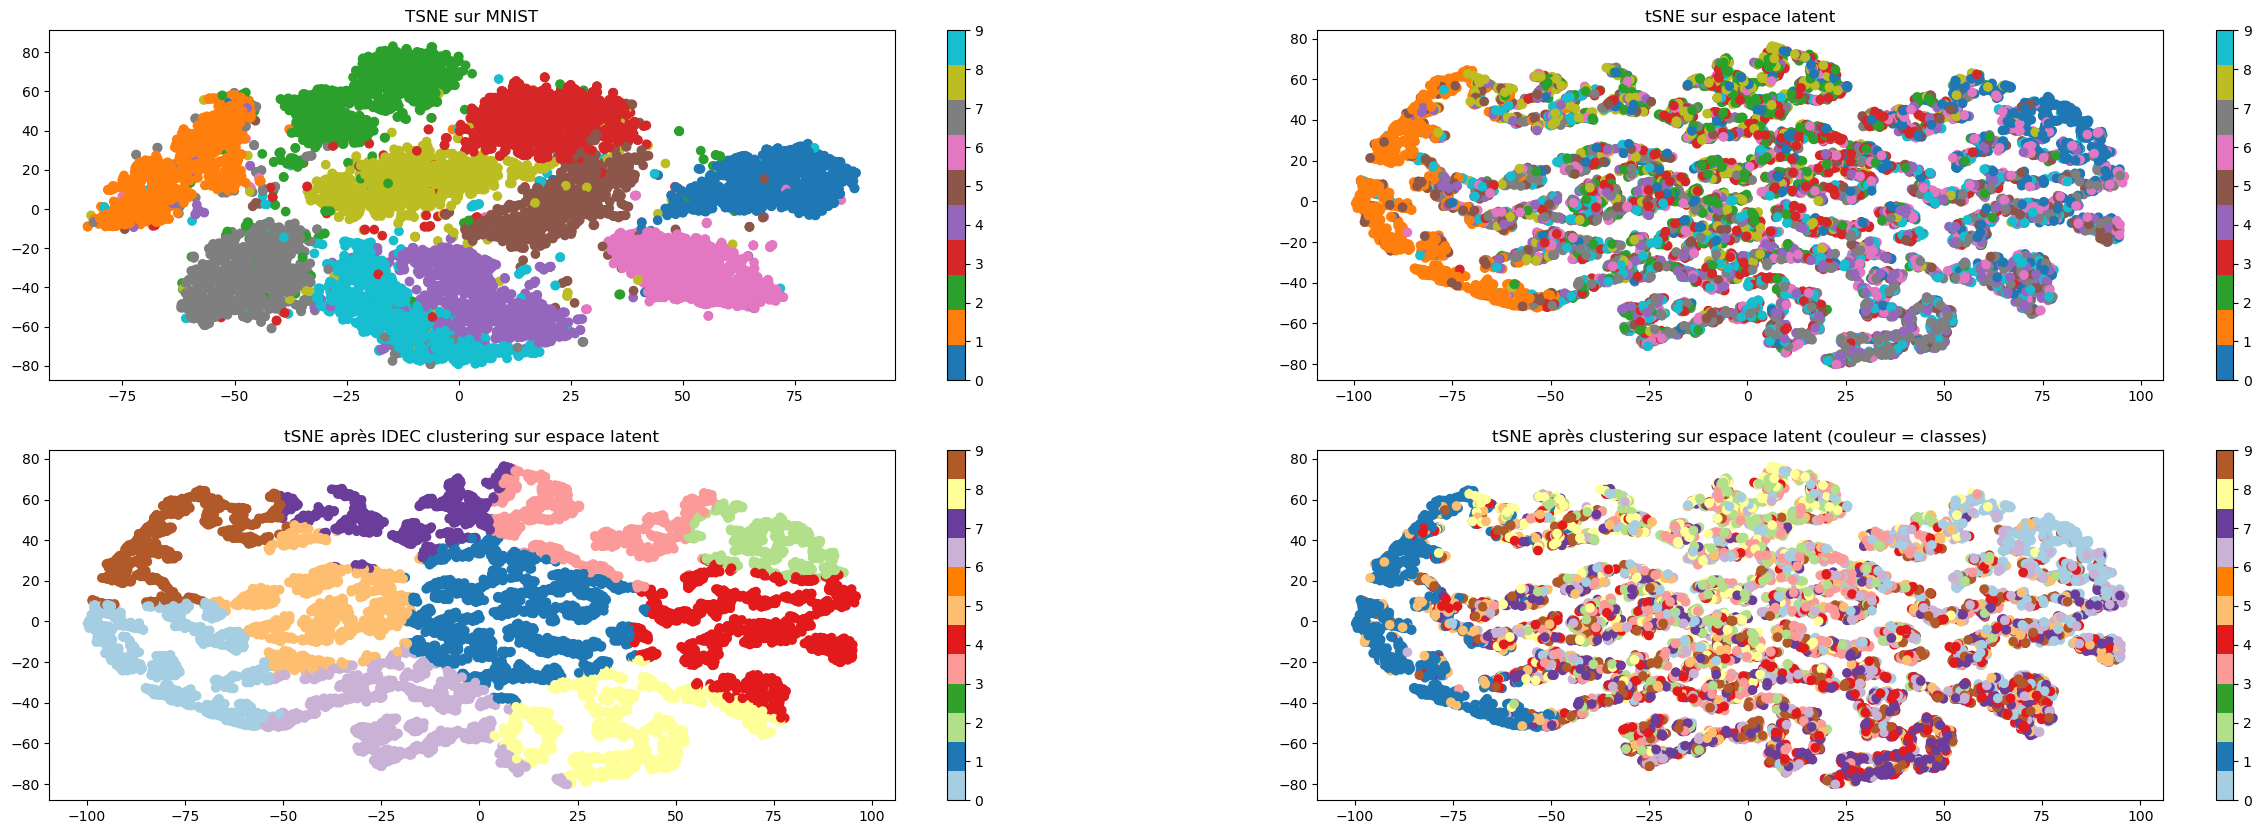

In [57]:
display_ClusteringImpact(x_test_rshp,classes,model_IDEC,encoder)

#### `4.12 Analyse des résultats`
__En résumé, visuellement c’est très propre__ : 
 - On voit bien la transition “clusters d’images → manifold latent continu → segmentation du manifold par K‑means”, 
 - Cela représente exactement ce que l’on doit identifier dans ce type d’expérience.

`En haut à gauche, le t‑SNE sur les images MNIST brutes` 
 - conserve une bonne séparation, mais avec des clusters encore un peu brouillons (chevauchement 4–9, 3–5, etc.).

`En haut à droite, le t‑SNE de l’espace latent` 
- Est clairement “enroulé” sur une sorte de manifold 1D continu
- Les classes sont mélangées le long du ruban, ce qui est typique d’un autoencodeur non supervisé qui code surtout la continuité des formes plutôt que la classe.

`En bas à gauche, le t‑SNE après clustering sur le latent` 
 - Montre que K‑means a parfaitement suivi le ruban et produit des segments bien nets, 
 - Ceci veut dire que la structure intrinsèque est très régulière.

`En bas à droite, le t‑SNE après clustering sur le latent par classes` 
 - Montre que certains segments du ruban sont dominés par une classe (bonne correspondance cluster↔classe), 
 - Alors que d’autres restent mixtes, ce qui reflète bien les limites du signal purement non supervisé.

__`Points positifs`__
 - L’espace latent est extrêmement régulier (une belle courbe continue), 
 - signe que l'encodeur capture une variable de “style/forme” principale, 
 - Ceci est intéressant pour de la manipulation des données depuis l'espace latent.
 - Le clustering sur cet espace marche très bien géométriquement (clusters compacts, frontières nettes), 
 - Donc le pipeline d’autoencodeur + K‑means est cohérent.

### __`V. Autoencoder version Convolutive`__

_`Détaillons les blocs :`_
0. Input
1. Conv2D(32)
2. MaxPooling2D
3. Conv2D(64)
4. MaxPooling2D
5. Conv2D(128) ← bottleneck (7×7×128)
6. UpSampling2D
7. Conv2D(64)
8. UpSampling2D
9. Conv2D(32)
10. Conv2D(1) ← sortie

#### `5.1 Architecture de l'autoencoder vs CNN`

In [58]:
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D # type: ignore

autoencoder = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2), padding="same"),         # 14x14x32
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2), padding="same"),         # 7x7x64
    Conv2D(128, (3,3), activation="relu", padding="same"),  # latent: 7x7x128
    # decoder
    UpSampling2D((2, 2)),                         # 14x14x128
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    UpSampling2D((2, 2)),                         # 28x28x64
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    Conv2D(1, (3, 3), activation="sigmoid", padding="same")  # sortie 28x28x1
])

#### `5.2 Formatage des données`

In [59]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

print(f"x_test.shape : {x_test.shape} x_train.shape : {x_train.shape}")

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test  = np.reshape(x_test,  (len(x_test), 28, 28, 1))
print(f"x_test.shape : {x_test.shape} x_train.shape : {x_train.shape}")

x_test.shape : (10000, 28, 28) x_train.shape : (60000, 28, 28)
x_test.shape : (10000, 28, 28, 1) x_train.shape : (60000, 28, 28, 1)


#### `5.3 Entrainement de l'autoencoder vs CNN`

In [60]:
autoencoder.compile(
    optimizer=Adam(5e-5),
    loss="mse",   
    metrics=["accuracy"],
)
# Entraînement de l'autoencodeur 
history = autoencoder.fit(x_train, x_train,
                epochs=25,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test, x_test)
                )

Epoch 1/25
469/469 [==============================] - 21s 44ms/step - loss: 0.0597 - accuracy: 0.8017 - val_loss: 0.0107 - val_accuracy: 0.8123
Epoch 2/25
469/469 [==============================] - 19s 41ms/step - loss: 0.0084 - accuracy: 0.8141 - val_loss: 0.0064 - val_accuracy: 0.8136
Epoch 3/25
469/469 [==============================] - 20s 42ms/step - loss: 0.0058 - accuracy: 0.8148 - val_loss: 0.0050 - val_accuracy: 0.8140
Epoch 4/25
469/469 [==============================] - 21s 44ms/step - loss: 0.0047 - accuracy: 0.8151 - val_loss: 0.0042 - val_accuracy: 0.8142
Epoch 5/25
469/469 [==============================] - 19s 41ms/step - loss: 0.0042 - accuracy: 0.8152 - val_loss: 0.0038 - val_accuracy: 0.8142
Epoch 6/25
469/469 [==============================] - 17s 36ms/step - loss: 0.0038 - accuracy: 0.8152 - val_loss: 0.0035 - val_accuracy: 0.8143
Epoch 7/25
469/469 [==============================] - 17s 36ms/step - loss: 0.0035 - accuracy: 0.8153 - val_loss: 0.0032 - val_accuracy:

##### _`5.3.1 Remarques`_
__1. L’accuracy n’a pas de sens pour un autoencodeur__
 - Sur un AE de reconstruction, la métrique utile est la loss, pas l’accuracy Keras. 
 - L’accuracy ici est une “binary_accuracy” pixel/pixel non interprétable pour la qualité de reconstruction.

#### `5.4 Définition de l'encoder / decoder vs CNN`

In [61]:
# Encoder et décoder quelques chiffres de l'ensemble test
from tensorflow.keras import Model, Input # type: ignore
# encoder = entrée -> couche bottleneck
_ = autoencoder(x_train[:1]) 

encoder = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.layers[5].output  # couche bottleneck
)
# 1) Récupérer la forme de la couche bottleneck
bottleneck_shape = autoencoder.layers[5].output_shape[1:]  # ex: (7, 7, 64)
# 2) Entrée latent de même forme
latent_input = Input(shape=bottleneck_shape)
# 3) Appliquer les couches de décodage (6 à la fin) sur cette entrée
x = latent_input
for layer in autoencoder.layers[6:]:
    x = layer(x)

decoder = Model(latent_input, x)

#### `5.5 Clustering basé sur Kmeans avec l'autoencoder vs CNN`

##### _`5.5.1 IDEC (Improved Deep Embedded Clustering)`_ 
C’est un algorithme de deep clustering qui part d’un autoencodeur “embedded” comme DEC, ajoute la loss de reconstruction en plus de la loss de clustering (KL), optimise les deux conjointement pour préserver la structure locale tout en améliorant la qualité des clusters

 - Modèle à 2 sorties optimisé par une loss jointe “reconstruction + clustering”, avec un coefficient γ. 
 - D’un point de vue Keras, c’est un modèle multi‑sorties avec une loss multi‑tâches pondérée :

   - outputs=[autoencoder.output, clustering_out],
   - loss=["binary_crossentropy", "kld"],
   - loss_weights=[1.0, gamma].

 - L’objectif IDEC : $L_{total}=L_r+γL_c$
   - $L_r$ loss de reconstruction (binary_crossentropy) et $L_c$ loss de clustering (kld entre p et q).
   - “un modèle IDEC avec optimisation jointe reconstruction + clustering”
   - ou plus génériquement “un multi‑task learning avec loss combinée. 

In [ ]:
print(x_train.shape)

In [62]:
gamma=1
lr=1e-4
loss=["kld","mse"]
model_IDEC, clustering_layer, y_pred_last, z_flatten, μj = buildModel(
                            x_train, lr,loss, n_clusters, gamma
                            )

235/235 [==============================] - 2s 8ms/step


#### `5.6 Entrainement du modèle de Clustering`

##### _`5.6.1 Axes d'amélioration`_
- Augmenter le poids de la loss de clustering (γ) et jouer sur le LR (ex. γ∈{0.5,1,2}, lr plus petit).
- Mettre à jour P moins souvent (toutes les 1–5 epochs complètes), 
- Permet de laisser le temps au réseau de s’adapter à une cible quasi fixe.
- Renforcer un peu le latent (par ex. 7×7×64 → 7×7×128 
- Ou bien ajouter une couche Dense dans le bottleneck) puis refaire KMeans + IDEC.

In [63]:
# paramètres à fixer
loss = 0.0
index = 0
maxiter = 20000          # assez grand pour plusieurs dizaines d'epochs effectives
batch_size = 256         # plus stable pour l’estimation de p
update_interval = 4 * (len(x_train) // batch_size)  # ≈ 1 epoch entre deux updates de p
tol = 1e-2  
index_array = np.arange(x_train.shape[0])

In [ ]:
print(x_train.shape)
print(y_train.shape)

In [ ]:
index,logs = trainingModel_IDEC(model_IDEC, x_train, y_train, y_pred_last,
                       index, batch_size, tol,
                       update_interval, maxiter, index_array)

(60000, 10)
(60000, 10)
(60000,)
(Iter , acc)   (0, 0.53458) ; loss = None
(60000, 10)
(60000, 10)
(60000,)
(Iter , acc)   (936, 0.51987) ; loss = 0.03535
(60000, 10)
(60000, 10)
(60000,)
(Iter , acc)   (1872, 0.50428) ; loss = 0.12253
(60000, 10)
(60000, 10)
(60000,)
(Iter , acc)   (2808, 0.49163) ; loss = 0.17718
(60000, 10)
(60000, 10)
(60000,)
(Iter , acc)   (3744, 0.47978) ; loss = 0.18721
(60000, 10)
(60000, 10)
(60000,)
(Iter , acc)   (4680, 0.47198) ; loss = 0.19357
(60000, 10)
(60000, 10)
(60000,)
(Iter , acc)   (5616, 0.4639) ; loss = 0.18814
(60000, 10)
(60000, 10)
(60000,)
(Iter , acc)   (6552, 0.45577) ; loss = 0.18591
(60000, 10)
(60000, 10)
(60000,)
(Iter , acc)   (7488, 0.45043) ; loss = 0.19436
(60000, 10)
(60000, 10)
(60000,)
(Iter , acc)   (8424, 0.44493) ; loss = 0.19607
(60000, 10)
(60000, 10)
(60000,)
(Iter , acc)   (9360, 0.43867) ; loss = 0.19728
(60000, 10)
(60000, 10)
(60000,)
(Iter , acc)   (10296, 0.43552) ; loss = 0.1996
(60000, 10)
(60000, 10)
(60000,)
(It

#### _`5.7 Affichage des résultats`_

In [ ]:
# Affichage de l'impact de cette couche clustering 
inputs = x_test
classes = y_test

# images pour conv
x_test_img = inputs.astype("float32") / 255.0
x_test_flat = x_test_img.reshape(len(x_test_img), -1)  # (N, 784)

print("x_test.shape :", x_test.shape)
print("x_test_img.shape :", x_test_img.shape)
print("x_test_flat.shape:", x_test_flat.shape)
print("encoder.input_shape:", encoder.input_shape)
print("encoder.output_shape:", encoder.output_shape)

In [ ]:
# soft labels finaux
_, q_final = model_IDEC.predict(inputs, batch_size=256, verbose=0)
y_pred_final = q_final.argmax(axis=1)

In [ ]:
from sklearn.metrics import accuracy_score
# ta fonction correspondance pour mapper les indices de clusters sur les labels MNIST
y_pred_mapped = correspondance(y_pred_final, y_test)
acc = accuracy_score(y_test, y_pred_mapped)
print("IDEC test acc :", acc)

In [ ]:
display_ClusteringImpact(x_test_flat,classes,model_IDEC,encoder)

Les quatre cartes t‑SNE sont cohérentes avec ce qu’indiquent les scores de clustering :

1. **t‑SNE sur MNIST (en haut à gauche)**  
   - Les classes sont très bien séparées en paquets compacts.  
   - Les chiffres bruts sont déjà très discriminants et que la classif supervisé atteint > 0.9.

2. **t‑SNE sur l’espace latent avant DEC (en haut à droite)**  
   - Les points sont beaucoup plus entremêlés : les couleurs (classes vraies) se mélangent fortement.  
   - C’est exactement ce que dit KMeans sur \(z\) (~0.32 d’accuracy)
   - L'autoencoder reconstruit bien mais ne force pas le latent à séparer les classes.

3. **t‑SNE après clustering, colorié par clusters (en bas à gauche)**  
   - On voit des zones où un cluster (une couleur) domine, mais beaucoup de recouvrement entre clusters.  
   - Normal pour un DEC qui n’a fait que légèrement “tirer” les centres sans changer la géométrie de \(z\).

4. **t‑SNE après clustering, colorié par classes (en bas à droite)**  
   - La structure globale reste proche de celle de l’espace latent non clusterisé
   - Les vraies classes restent mélangées, avec quelques régions plus homogènes.  
   - Ça correspond bien à l'accuracy DEC autour de 0.33–0.35
   - Un gain modeste par rapport à KMeans seul, pas une séparation nette.

En résumé, la visualisation confirme :  
- MNIST brut → classes bien séparées.  
- Latent de l’autoencodeur → bon pour la reconstruction, mais pas “class‑disentangled”.  
- DEC tel qu’implémenté → améliore un peu les clusters, 
- Mais ne parvient pas à aligner fortement les classes dans cet espace latent. 
- Pour gagner en séparation, il faudrait soit un encodeur explicitement régularisé pour le clustering (type IDEC/variantes), 
- soit une combinaison plus agressive reconstruction + clustering dans l’entraînement.

In [ ]:
n = 20  # Combien de chiffres nous allons afficher
# Afficher l'image reconstruite à partir de l'espace latent après entraînement
# encoder / decoder
encoded_imgs = encoder.predict(x_test_img[:n])
decoded_imgs = decoder.predict(encoded_imgs)

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 2))
for i in range(n):
    # original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_rshp[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # reconstruit
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.show()